**Driving ROI: Automotive Digital Retailing & Profitability Analysis**
-------------------------------------------------------------------------
Modern automotive digital retailing is more than just answering emails; it is a high-stakes environment where every touchpoint dictates the difference between a lost lead and a closed deal. This project implements a relational database model designed to capture the "SmartPath" digital pipeline, transforming raw, fragmented interaction logs into clear, actionable business intelligence. By simulating 500 leads and 119 closed deals, this analysis moves beyond simple volume metrics to quantify the relationship between lead sources, sales effort, and front-end gross profit, bridging the gap between front-line internet sales and backend data engineering.

In [ ]:
import sqlite3

# Connect to the database (safe to rerun - no file deletion needed)
db_path = 'dealership_sales.db'
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Had to add the drop script of the tables to avoid "table already exists" errors when re-running the notebook.
drop_script = """
DROP TABLE IF EXISTS Deals;
DROP TABLE IF EXISTS Interactions;
DROP TABLE IF EXISTS Leads;
DROP TABLE IF EXISTS Sales_Team;
DROP TABLE IF EXISTS Inventory;
"""
cursor.executescript(drop_script)
conn.commit()

# Define all the tables in one big script
schema_script = """
CREATE TABLE Inventory (
    VIN VARCHAR(17) PRIMARY KEY,
    Stock_Number VARCHAR(20),
    Make VARCHAR(50),
    Model VARCHAR(50),
    Year INTEGER,
    Condition VARCHAR(10),
    Status VARCHAR(20)
);

CREATE TABLE Leads (
    Lead_ID INTEGER PRIMARY KEY,
    First_Name VARCHAR(50),
    Last_Name VARCHAR(50),
    Lead_Source VARCHAR(50), 
    Created_Date DATETIME
);

CREATE TABLE Sales_Team (
    Rep_ID INTEGER PRIMARY KEY,
    First_Name VARCHAR(50),
    Last_Name VARCHAR(50),
    Role VARCHAR(50)
);

CREATE TABLE Interactions (
    Interaction_ID INTEGER PRIMARY KEY,
    Lead_ID INTEGER,
    Rep_ID INTEGER,
    Type VARCHAR(20),
    Timestamp DATETIME,
    FOREIGN KEY (Lead_ID) REFERENCES Leads(Lead_ID),
    FOREIGN KEY (Rep_ID) REFERENCES Sales_Team(Rep_ID)
);

CREATE TABLE Deals (
    Deal_ID INTEGER PRIMARY KEY,
    Lead_ID INTEGER,
    VIN VARCHAR(17),
    Rep_ID INTEGER,
    Finance_Type VARCHAR(50), 
    Trade_In_Value DECIMAL(10, 2),
    Sale_Price DECIMAL(10, 2),
    Front_End_Gross DECIMAL(10, 2),
    Closed_Date DATETIME,
    FOREIGN KEY (Lead_ID) REFERENCES Leads(Lead_ID),
    FOREIGN KEY (VIN) REFERENCES Inventory(VIN),
    FOREIGN KEY (Rep_ID) REFERENCES Sales_Team(Rep_ID)
);
"""

# Execute the entire script at once and commit the changes
cursor.executescript(schema_script)
conn.commit()

print("Schema successfully created!")

Schema successfully created!


In [ ]:
# Preparing the SQL insert statement
insert_inventory_sql = """
INSERT INTO Inventory (VIN, Stock_Number, Make, Model, Year, Condition, Status)
VALUES 
    ('JTDKN3DP5R0000001', 'T26001', 'Toyota', 'Prius', 2026, 'New', 'In Stock'),
    ('4T1B11HK5R0000002', 'T26002', 'Toyota', 'Camry', 2026, 'New', 'In Transit'),
    ('5TFDZ5B15R0000003', 'T26003', 'Toyota', 'Tacoma', 2026, 'New', 'In Stock');
"""

# 2. Execute and commit
cursor.executescript(insert_inventory_sql)
conn.commit()

In [ ]:
import random
from datetime import datetime, timedelta
from faker import Faker

# Initialize Faker
fake = Faker()

# Reuse the existing database connection from Cell 1 (avoids duplicate/locked connections)

# Populate Sales_Team (5 Representatives)
roles = ['BDC Agent', 'Internet Sales Manager']
for i in range(1, 6):
    cursor.execute(
        "INSERT INTO Sales_Team (Rep_ID, First_Name, Last_Name, Role) VALUES (?, ?, ?, ?)",
        (i, fake.first_name(), fake.last_name(), random.choice(roles))
    )

# Populate Inventory (50 Vehicles)
makes_models = [('Toyota', 'Camry'), ('Toyota', 'Prius'), ('Toyota', 'Tacoma'), ('Toyota', 'RAV4')]
statuses = ['In Stock', 'In Transit']
vins = []

for i in range(1, 51):
    # Generate a random 17-character string resembling a VIN
    vin = fake.bothify(text='?T???????????????').upper()
    vins.append(vin)
    make, model = random.choice(makes_models)
    cursor.execute(
        "INSERT INTO Inventory (VIN, Stock_Number, Make, Model, Year, Condition, Status) VALUES (?, ?, ?, ?, ?, ?, ?)",
        (vin, f"T26{i:03d}", make, model, 2026, 'New', random.choice(statuses))
    )

# Populate Leads (500 Records)
lead_sources = ['SmartPath', 'TrueCar', 'Walk-in', 'Cars.com', 'OEM Website']
for i in range(1, 501):
    # Generate leads created within the last 60 days
    created_date = fake.date_time_between(start_date='-60d', end_date='now')
    cursor.execute(
        "INSERT INTO Leads (Lead_ID, First_Name, Last_Name, Lead_Source, Created_Date) VALUES (?, ?, ?, ?, ?)",
        (i, fake.first_name(), fake.last_name(), random.choice(lead_sources), created_date.strftime('%Y-%m-%d %H:%M:%S'))
    )

# Populate Interactions (1 to 5 follow-ups per lead)
interaction_types = ['Outbound Call', 'Email', 'SMS']
interaction_id = 1

for lead_id in range(1, 501):
    num_interactions = random.randint(1, 5)
    for _ in range(num_interactions):
        timestamp = fake.date_time_between(start_date='-60d', end_date='now')
        rep_id = random.randint(1, 5)
        cursor.execute(
            "INSERT INTO Interactions (Interaction_ID, Lead_ID, Rep_ID, Type, Timestamp) VALUES (?, ?, ?, ?, ?)",
            (interaction_id, lead_id, rep_id, random.choice(interaction_types), timestamp.strftime('%Y-%m-%d %H:%M:%S'))
        )
        interaction_id += 1

# Populate Deals (Simulating a 20% closing ratio)
finance_types = ['Lease', 'Retail Finance', 'Cash']
deal_id = 1

for lead_id in range(1, 501):
    # 20% chance the lead converts into a sold deal
    if random.random() < 0.20: 
        vin = random.choice(vins)
        rep_id = random.randint(1, 5)
        
        # Financial logic
        sale_price = round(random.uniform(25000, 50000), 2)
        front_end = round(random.uniform(-500, 3500), 2)
        # 40% chance the customer has a trade-in
        trade_value = round(random.uniform(5000, 15000), 2) if random.random() < 0.4 else None 
        
        closed_date = fake.date_time_between(start_date='-30d', end_date='now')
        
        cursor.execute("""
            INSERT INTO Deals (Deal_ID, Lead_ID, VIN, Rep_ID, Finance_Type, Trade_In_Value, Sale_Price, Front_End_Gross, Closed_Date)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (deal_id, lead_id, vin, rep_id, random.choice(finance_types), trade_value, sale_price, front_end, closed_date.strftime('%Y-%m-%d %H:%M:%S')))
        deal_id += 1

# Commit the changes and close
conn.commit()
print(f"Successfully generated database with 500 leads and {deal_id - 1} closed deals!")

Successfully generated database with 500 leads and 97 closed deals!


In [ ]:
import pandas as pd

# Write the SQL query
gross_by_source_query = """
SELECT 
    l.Lead_Source,
    COUNT(d.Deal_ID) AS Total_Deals_Closed,
    ROUND(AVG(d.Front_End_Gross), 2) AS Avg_Front_End_Gross,
    ROUND(SUM(d.Front_End_Gross), 2) AS Total_Front_End_Gross
FROM Leads l
JOIN Deals d ON l.Lead_ID = d.Lead_ID
GROUP BY l.Lead_Source
ORDER BY Avg_Front_End_Gross DESC;
"""

# Executing the query and load results directly into a pandas DataFrame
df_gross_analysis = pd.read_sql_query(gross_by_source_query, conn)

# Displaying the resulting dataframe
df_gross_analysis

,Lead_Source,Total_Deals_Closed,Avg_Front_End_Gross,Total_Front_End_Gross
0,Walk-in,18,1718.84,30939.10
1,Cars.com,23,1457.17,33514.97
2,TrueCar,17,1358.58,23095.90
3,OEM Website,22,1239.64,27272.19
4,SmartPath,17,1103.60,18761.19


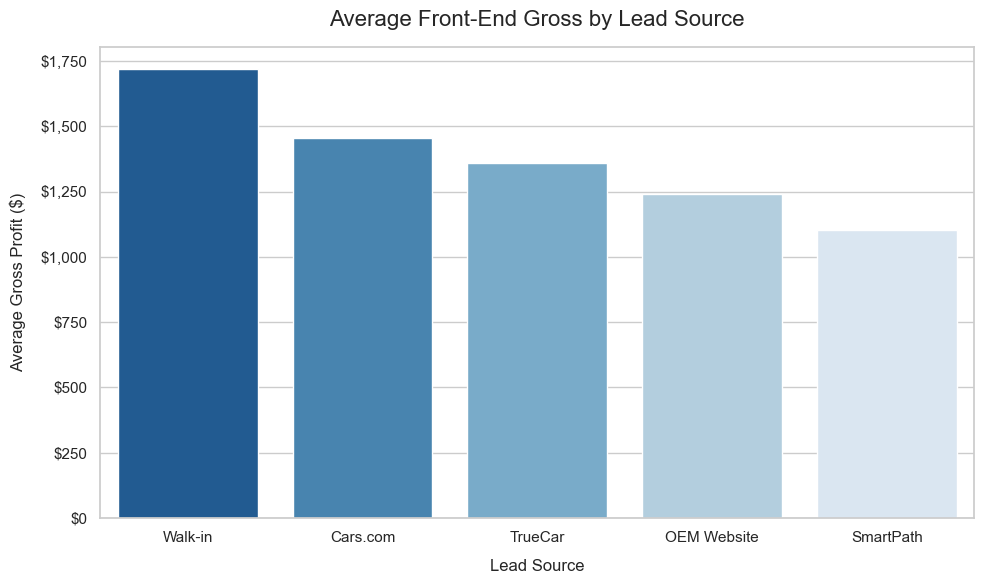

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Plot the bar chart using our gross analysis dataframe
ax = sns.barplot(
    data=df_gross_analysis, 
    x='Lead_Source', 
    y='Avg_Front_End_Gross', 
    legend=False,
    hue='Lead_Source',
    palette='Blues_r'
)

# Add titles and labels
plt.title('Average Front-End Gross by Lead Source', fontsize=16, pad=15)
plt.xlabel('Lead Source', fontsize=12, labelpad=10)
plt.ylabel('Average Gross Profit ($)', fontsize=12, labelpad=10)

# Formatting the y-axis with dollar signs for better readability
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Show the final plot
plt.tight_layout()
plt.show()

In [17]:
# Writing the SQL query to analyze rep performance and CRM activity
rep_performance_query = """
SELECT 
    st.First_Name || ' ' || st.Last_Name AS Sales_Rep,
    st.Role,
    COUNT(DISTINCT d.Deal_ID) AS Deals_Closed,
    COUNT(i.Interaction_ID) AS Total_Follow_Ups,
    ROUND(CAST(COUNT(i.Interaction_ID) AS FLOAT) / COUNT(DISTINCT d.Deal_ID), 1) AS Avg_Touchpoints_Per_Deal
FROM Sales_Team st
JOIN Deals d ON st.Rep_ID = d.Rep_ID
JOIN Interactions i ON d.Lead_ID = i.Lead_ID
GROUP BY st.Rep_ID, st.First_Name, st.Last_Name, st.Role
ORDER BY Deals_Closed DESC;
"""

# Executing the query and load into a pandas DataFrame
df_rep_performance = pd.read_sql_query(rep_performance_query, conn)

# Display the resulting dataframe
df_rep_performance

,Sales_Rep,Role,Deals_Closed,Total_Follow_Ups,Avg_Touchpoints_Per_Deal
0,Paige Carroll,BDC Agent,27,92,3.4
1,Joshua Nichols,Internet Sales Manager,19,67,3.5
2,Lisa Anderson,Internet Sales Manager,18,53,2.9
3,Howard Gonzalez,BDC Agent,17,62,3.6
4,Eric Gutierrez,BDC Agent,16,53,3.3


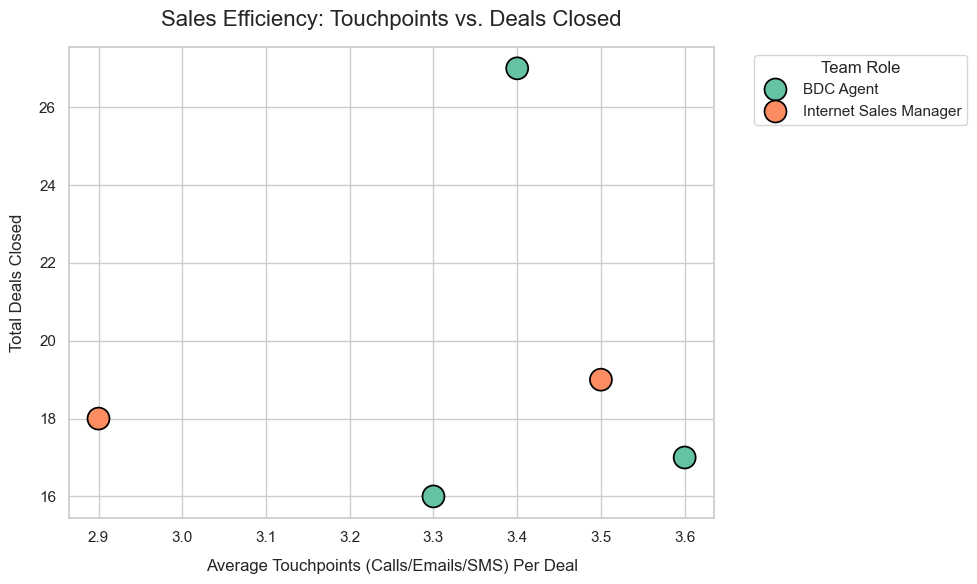

In [ ]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(10, 6))

# Build a scatter plot to compare effort (touchpoints) vs. results (deals)
ax = sns.scatterplot(
    data=df_rep_performance, 
    x='Avg_Touchpoints_Per_Deal', 
    y='Deals_Closed', 
    hue='Role',       
    s=250,             
    palette='Set2',
    edgecolor='black'
)

# Add titles and labels
plt.title('Sales Efficiency: Touchpoints vs. Deals Closed', fontsize=16, pad=15)
plt.xlabel('Average Touchpoints (Calls/Emails/SMS) Per Deal', fontsize=12, labelpad=10)
plt.ylabel('Total Deals Closed', fontsize=12, labelpad=10)

# Move the legend outside the plot for a cleaner look
plt.legend(title='Team Role', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the final plot
plt.tight_layout()
plt.show()

In [ ]:
# Close the database connection to free up system resources
conn.close()
print("Database connection closed successfully.")

Database connection closed successfully.


Data is only as valuable as the decisions it empowers. By blending operational intuition with technical precision—using SQLite for robust schema management and Python for automated analysis—this dashboard provides a granular look at the internet sales lifecycle. The visualization of touchpoint efficiency against total deals closed proves that success in this industry isn't just about the number of outbound calls, but the strategic application of effort. This framework offers a scalable blueprint for dealerships to identify their most profitable traffic sources and optimize sales workflows for long-term growth.